# Algoritmos supervisados o semi-supervisados: Usando los datos de K-Means

In [21]:
from pyspark.sql import SparkSession

# 1. Iniciamos Spark en este nuevo notebook
spark = SparkSession.builder.appName("Semana12_Supervisados").getOrCreate()

# 2. Leemos DIRECTAMENTE los datos que guardamos en el Paso 1
ruta_datos = "/home/jovyan/work/semanas/Semana 10/modelos/datos_etiquetados_kmeans"
df_clusters = spark.read.parquet(ruta_datos)

# 4. Mostramos la tabla para comprobar que TODO está ahí
df_clusters.select("marca", "precio_kg", "rating", "prediction").show(10)

+-----+-----------------+-----------------+----------+
|marca|        precio_kg|           rating|prediction|
+-----+-----------------+-----------------+----------+
|    0|9.020000457763672|4.800000190734863|         1|
|    1|6.860000133514404|4.699999809265137|         0|
|    3|5.150000095367432|4.699999809265137|         0|
|    1|5.349999904632568|4.699999809265137|         0|
|    0|7.639999866485596|4.800000190734863|         1|
|    1|9.359999656677246|4.900000095367432|         0|
|    3|4.670000076293945|4.800000190734863|         0|
|    0|7.510000228881836|4.800000190734863|         1|
|    3|4.670000076293945|4.699999809265137|         0|
|    0|8.739999771118164|4.800000190734863|         1|
+-----+-----------------+-----------------+----------+
only showing top 10 rows



## Árbol de Decisión

In [18]:
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# 1. Renombramos 'prediction' a 'label' para el modelo supervisado
df_supervisado = df_clusters.withColumnRenamed("prediction", "label")

# 2. Dividimos los datos en Entrenamiento (70%) y Prueba (30%)
train_data, test_data = df_supervisado.randomSplit([0.7, 0.3], seed=42)

print(f"Datos de entrenamiento: {train_data.count()}")
print(f"Datos de prueba: {test_data.count()}")

Datos de entrenamiento: 679
Datos de prueba: 236


In [22]:
# Configurar el modelo supervisado
# Usamos 'scaledFeatures' como entrada (featuresCol) y 'label' como el grupo a predecir
dt = DecisionTreeClassifier(featuresCol="scaledFeatures", labelCol="label", maxDepth=5, seed=42)

# Entrenar el modelo con los datos de entrenamiento
dt_model = dt.fit(train_data)

# Hacer predicciones sobre los datos de prueba
predictions_supervisadas = dt_model.transform(test_data)

# Mostrar las primeras predicciones junto a la etiqueta real del K-Means
predictions_supervisadas.select("marca", "label", "prediction", "probability").show(10)

+-----+-----+----------+-------------+
|marca|label|prediction|  probability|
+-----+-----+----------+-------------+
|    0|    2|       2.0|[0.0,0.0,1.0]|
|    0|    2|       2.0|[0.0,0.0,1.0]|
|    0|    2|       2.0|[0.0,0.0,1.0]|
|    0|    2|       2.0|[0.0,0.0,1.0]|
|    0|    2|       2.0|[0.0,0.0,1.0]|
|    0|    2|       2.0|[0.0,0.0,1.0]|
|    0|    2|       2.0|[0.0,0.0,1.0]|
|    0|    2|       2.0|[0.0,0.0,1.0]|
|    0|    2|       2.0|[0.0,0.0,1.0]|
|    0|    2|       2.0|[0.0,0.0,1.0]|
+-----+-----+----------+-------------+
only showing top 10 rows



In [23]:
# Evaluar la precisión
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions_supervisadas)

print(f"Precisión del Árbol de Decisión (Accuracy): {accuracy * 100:.2f}%")

Precisión del Árbol de Decisión (Accuracy): 100.00%


In [26]:
print("=== ESTRUCTURA LÓGICA DEL ÁRBOL ===")
print(dt_model.toDebugString)

=== ESTRUCTURA LÓGICA DEL ÁRBOL ===
DecisionTreeClassificationModel: uid=DecisionTreeClassifier_18c7bc4ef974, depth=3, numNodes=15, numClasses=3, numFeatures=4
  If (feature 2 <= 1.1857852061682543)
   If (feature 0 <= 3.548416709314404)
    If (feature 3 <= 2.2847094296863824)
     Predict: 0.0
    Else (feature 3 > 2.2847094296863824)
     Predict: 1.0
   Else (feature 0 > 3.548416709314404)
    If (feature 0 <= 4.15166587269519)
     Predict: 1.0
    Else (feature 0 > 4.15166587269519)
     Predict: 2.0
  Else (feature 2 > 1.1857852061682543)
   If (feature 0 <= 2.467671484497751)
    If (feature 3 <= 1.4554022625520897)
     Predict: 0.0
    Else (feature 3 > 1.4554022625520897)
     Predict: 1.0
   Else (feature 0 > 2.467671484497751)
    If (feature 0 <= 4.15166587269519)
     Predict: 1.0
    Else (feature 0 > 4.15166587269519)
     Predict: 2.0



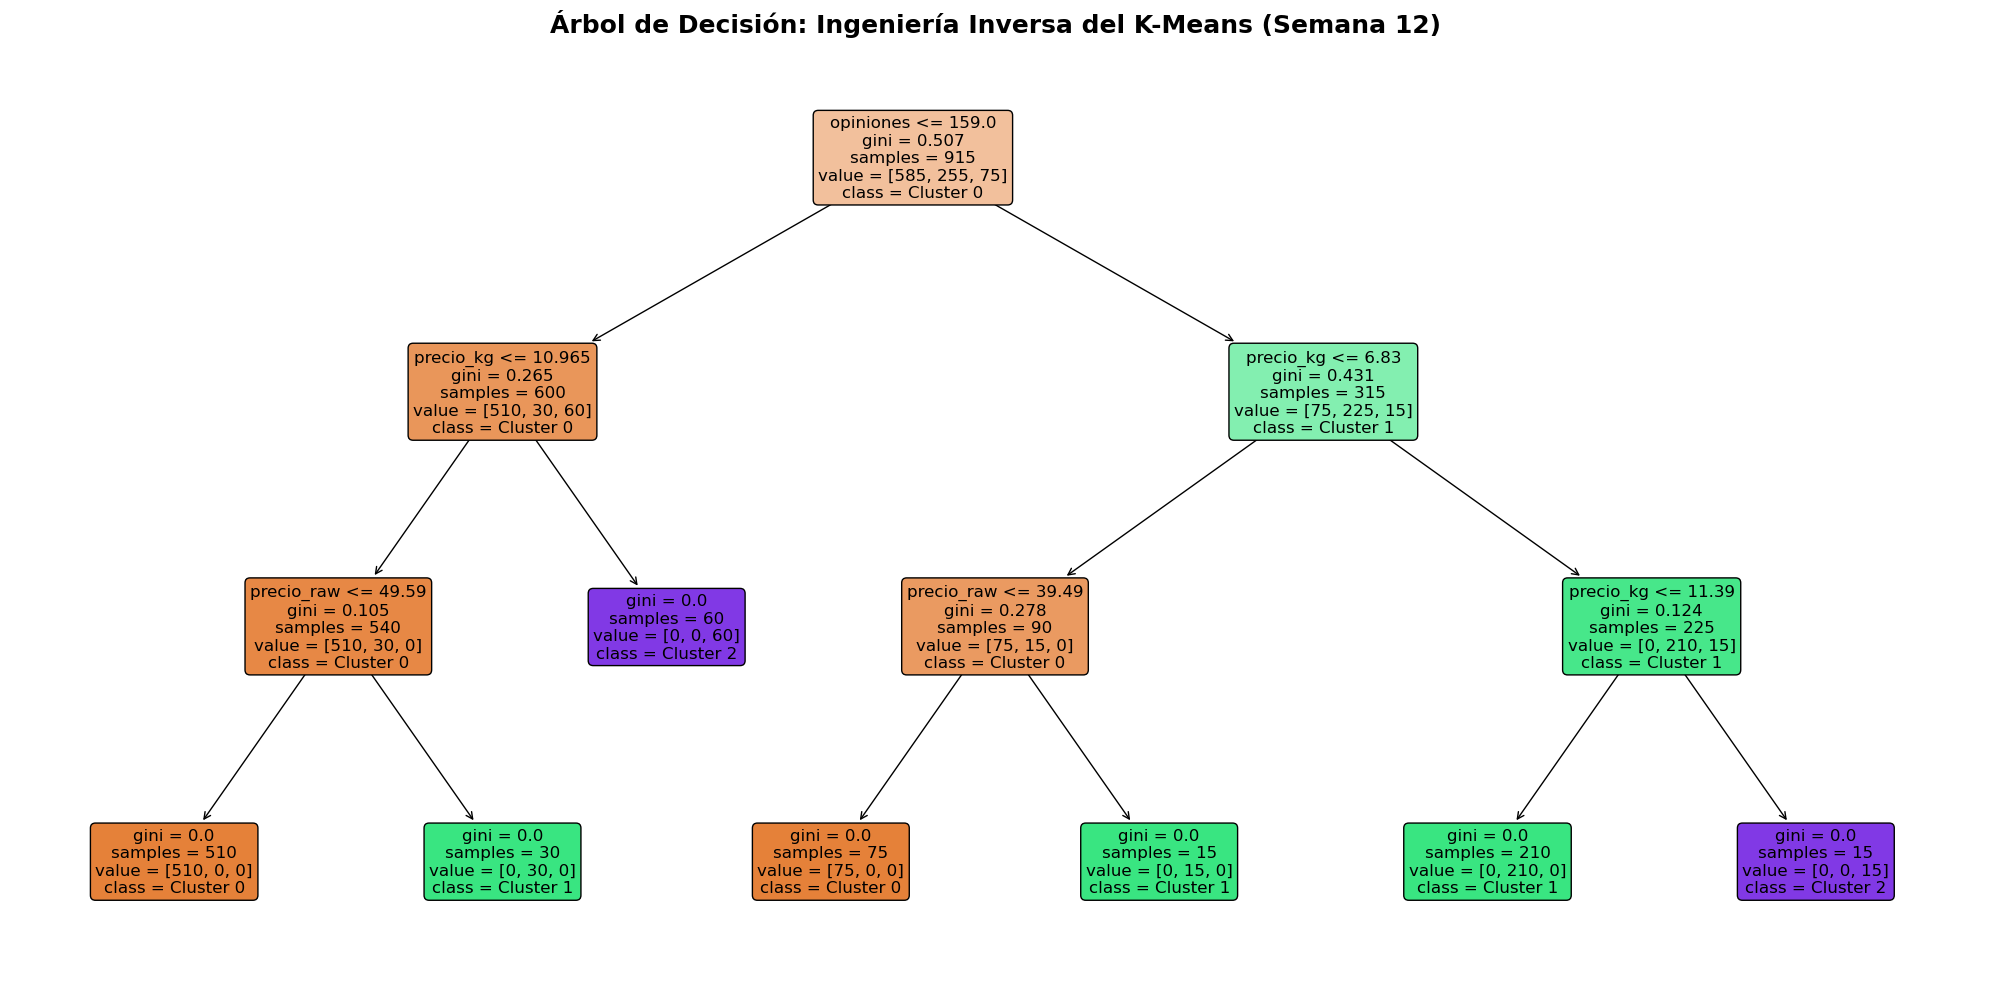

In [25]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier as SklearnClassifier

# 1. Convertimos una muestra de nuestro DataFrame de Spark a Pandas para Scikit-Learn
df_pandas = df_supervisado.select("precio_kg", "rating", "opiniones", "precio_raw", "label").toPandas()

# 2. Separamos las características (X) y la etiqueta (y)
X_muestra = df_pandas[["precio_kg", "rating", "opiniones", "precio_raw"]]
y_muestra = df_pandas["label"]

# 3. Creamos ENTRENAMOS el modelo de Scikit-Learn (¡Aquí es donde se corrige el error!)
sk_dt = SklearnClassifier(max_depth=3, random_state=42) # Limitamos la profundidad a 3 para que no sea gigante
sk_dt.fit(X_muestra, y_muestra)

# 4. Configuramos las etiquetas para el gráfico
nombres_features = ["precio_kg", "rating", "opiniones", "precio_raw"]
# Convertimos los números de cluster a texto para que sea más didáctico
nombres_clases = [f"Cluster {int(c)}" for c in sorted(y_muestra.unique())]

# 5. Dibujamos el árbol de forma visual
plt.figure(figsize=(20, 10), dpi=100) # Tamaño grande y buena resolución
plot_tree(sk_dt, 
          feature_names=nombres_features, 
          class_names=nombres_clases, 
          filled=True,      # Le pone colores según la clase mayoritaria
          rounded=True,     # Bordes redondeados para estética
          fontsize=12)      # Tamaño de letra legible

plt.title("Árbol de Decisión: Ingeniería Inversa del K-Means (Semana 12)", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

# Algoritmo Supervisado: Random Forest (Bosques aleatorios), Support Vector Machine (Máquinas de Vector de Soporte), regresión logística multinomial

In [27]:
# 1. Renombramos 'prediction' (del K-Means) a 'label'
df_supervisado = df_recuperado.withColumnRenamed("prediction", "label")

# 2. Dividimos en 70% entrenamiento y 30% prueba
train_data, test_data = df_supervisado.randomSplit([0.7, 0.3], seed=42)

print(f"Registros de Entrenamiento: {train_data.count()}")
print(f"Registros de Prueba: {test_data.count()}")

Registros de Entrenamiento: 679
Registros de Prueba: 236


In [28]:
from pyspark.ml.classification import RandomForestClassifier, LinearSVC, LogisticRegression, OneVsRest
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Creamos el evaluador común para medir el Accuracy
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")

# ==========================================
# MODELO 1: Random Forest (Bosque Aleatorio)
# ==========================================
# Nota: Los árboles pueden usar 'features' (sin escalar) o 'scaledFeatures'. Usaremos 'scaledFeatures' por homogeneidad.
rf = RandomForestClassifier(featuresCol="scaledFeatures", labelCol="label", numTrees=20, seed=42)
rf_model = rf.fit(train_data)
rf_predictions = rf_model.transform(test_data)
accuracy_rf = evaluator.evaluate(rf_predictions)

# ==========================================
# MODELO 2: SVM (Máquina de Vectores de Soporte)
# ==========================================
# NOTA PARA LA CLASE: En PySpark, LinearSVC solo soporta clasificación binaria (0 o 1). 
# Como el K-Means generó 3 clusters (0, 1, 2), usamos la estrategia 'OneVsRest' (Uno contra todos) 
# para permitir que el SVM clasifique múltiples clases.
svm_binario = LinearSVC(featuresCol="scaledFeatures", labelCol="label", maxIter=10)
ovr_svm = OneVsRest(classifier=svm_binario, labelCol="label", featuresCol="scaledFeatures")
svm_model = ovr_svm.fit(train_data)
svm_predictions = svm_model.transform(test_data)
accuracy_svm = evaluator.evaluate(svm_predictions)

# ==========================================
# MODELO 3: Regresión Logística Multinomial
# ==========================================
# Ideal para problemas multiclase y calcula probabilidades por cada cluster.
lr = LogisticRegression(featuresCol="scaledFeatures", labelCol="label", maxIter=10, family="multinomial")
lr_model = lr.fit(train_data)
lr_predictions = lr_model.transform(test_data)
accuracy_lr = evaluator.evaluate(lr_predictions)

In [29]:
print("==================================================")
print("  RESULTADOS DE MODELOS SUPERVISADOS (SEMANA 12)  ")
print("==================================================")
print(f"1. Random Forest Accuracy:      {accuracy_rf * 100:.2f}%")
print(f"2. SVM (OneVsRest) Accuracy:    {accuracy_svm * 100:.2f}%")
print(f"3. Regresión Logística Accuracy:{accuracy_lr * 100:.2f}%")
print("==================================================")

  RESULTADOS DE MODELOS SUPERVISADOS (SEMANA 12)  
1. Random Forest Accuracy:      100.00%
2. SVM (OneVsRest) Accuracy:    100.00%
3. Regresión Logística Accuracy:100.00%
